Recall that the analytical posterior for our model is 

$$\theta | x=x_\text{obs} \sim N_{[-L, L]^d}(x_\text{obs}, \sigma^2 I_d)$$

Suppose we set $\sigma^2 = 1$ and we condition on observing $x_\text{obs}=0$, then our posterior is

$$\theta | x=0 \sim N_{[-L, L]^d}(0, I_d)$$

In this case, we aim to select the uniform bounds of the form $[-L, L]^d$ such that the posterior is approximately Gaussian (i.e. the truncation is neglible, because most of the mass of the Gaussian is inside $[-L, L]^d$). We can find an exact expression for $L$ since the elements of our posterior vectors are independent $N(0,1)$:

$$P\left( \bigcap_{i=1}^d \{\theta_i \in [-L,L]\} \right) = \prod_{i=1}^d P\left(\theta_i \in [-L,L]\right)$$

$$ = \left( \Phi(L) - \Phi(-L)\right)^d = \left( 2\Phi(L) - 1\right)^d$$

Thus, if we want a cube region that contains the vector with probability $p^* \in [0,1]$, we solve

$$\left( 2\Phi(L) - 1\right)^d \overset{\text{set}}{=} p^*$$

$$\implies L = \Phi^{-1}\left( \frac{(p^*)^\frac{1}{d} + 1}{2}\right)$$

We can also obtain a spherical CI for the vector, using the fact that $||\theta||^2 \sim \chi^2_d$:

$$P\left(||\theta|| \le R \right) = P\left(||\theta||^2 \le R^2 \right)$$

$$=F_{\chi^2_d}(R^2)$$

Thus, if we want a spherical region that contains the vector with probability $p^* \in [0,1]$, we solve

$$F_{\chi^2_d}(R^2) = p^*$$

$$\implies R = \sqrt{F_{\chi^2_d}^{-1}(p^*)}$$

Note that, for fixed $p^*$, the spherical CI clearly "spills outside" of the box CI. However, we choose to select $L$ to equal the radius of the spherical CI:

$$L = R = \sqrt{F_{\chi^2_d}^{-1}(p^*)}$$

which ensures that the $p^*$ probability region containing the vector is a sphere inscribed within the prior bounds. This allows us to examine what happens as we increase the dimension $d$, since the volume ratio of the $p^*$ probability sphere of the posterior divided by the volume of the prior bounds :

$$\frac{\text{vol}\left( \{\theta : ||\theta|| \le L\} \right)}{\text{vol}([-L,L]^d)} = \frac{\pi^{d/2}L^d}{(2L)^d \Gamma(1 + d/2)} = \left(\frac{\sqrt{\pi}}{2}\right)^d\frac{1}{\Gamma(1 + d/2)}$$

goes to zero as $d \to \infty$.

Intuitively, $p^*$ (usually 0.99) of the posterior mass is contained within the sphere with radius $L$, and this sphere is inscribed inside the prior region $[-L,L]^d$, where the ratio of the volume of the $p^*$ region to the volume of the prior region goes to zero as $d \to \infty$. Thus, we expect the inference algorithms to struggle as $d$ gets larger, since the prior mass region becomes tiny compared to the prior region.

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sbi.analysis import pairplot
import yaml
import scipy

# Import local packages
from examples.unif_norm import (
    prior_pdf,
    get_approximate_posterior_density,
    true_posterior_pdf,
    approximate_posterior_quantiles_against_x,
    plot_approximate_posterior_quantiles_against_x,
    plot_approximate_posterior_quantiles_diff_against_x,
    plot_leakage_factors
)
from sbc.sbc_tools import plot_sbc_all
results_path_npe_c = "/Users/Lieve/Documents/Masters Project/SBC-SBI/results/toy_examples/unif_norm/npe_c/"
results_path_tsnpe = "/Users/Lieve/Documents/Masters Project/SBC-SBI/results/toy_examples/unif_norm/tsnpe/"
algorithm_names = ["npe_c", "tsnpe", "nle_mcmc", "nle_vi", "nre"]
algorithm_KLs_squared_norms_ID = {"npe_c": 0,
                                  "tsnpe": 0,
                                  "nle_mcmc": 0,
                                  "nle_vi": 0,
                                  "nre": 0} # The ID of the experiment in each algorithm directory

In [7]:
KLs_dicts = {}
KLs_squared_norms_configs = {}

for algorithm_name in algorithm_names:
    KLs_squared_norms_ID = algorithm_KLs_squared_norms_ID[algorithm_name]

    results_path = "/Users/Lieve/Documents/Masters Project/SBC-SBI/results/toy_examples/unif_norm" + f"/{algorithm_name}/"
    config_path = results_path + f"KLs_squared_norms{KLs_squared_norms_ID}.yaml"
    KLs_path = results_path + f"KLs_squared_norms{KLs_squared_norms_ID}_KLs_dict.npz"

    # Load config
    with open(config_path, "r") as f:
        KLs_squared_norms_config = yaml.safe_load(f)
    KLs_squared_norms_configs[algorithm_name] = KLs_squared_norms_config

    # Load squared norms
    KLs_dict = dict(np.load(KLs_path))
    KLs_dicts[algorithm_name] = KLs_dict



In [8]:
def plot_KL_across_rounds(KLs_dicts, exclude_rounds=None, exclude_methods=None):
    if exclude_rounds is None:
        exclude_rounds = []
    if exclude_methods is None:
        exclude_methods = []

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.set_xlabel("Round")
    ax.set_ylabel(r"$KL\left(\tilde{\pi}(\theta|x)\|\pi(\theta|x)\right)$")
    ax.set_title("KL(approximate posterior || true posterior) across rounds")

    global_rs = set()

    # Loop over algorithms
    for method_name, KLs_dict in KLs_dicts.items():
        if method_name not in exclude_methods:
            rs = []
            mean_KLs = []
            SEs = []
            r = 0
            while f"round_{r}" in KLs_dict:
                if r not in exclude_rounds:

                    KLs = np.asarray(KLs_dict[f"round_{r}"])

                    # Handle scalar or single repetition safely
                    if KLs.ndim == 0:
                        KLs = KLs[np.newaxis]

                    R = len(KLs)

                    mean_KLs.append(np.mean(KLs))

                    if R > 1:
                        SEs.append(np.std(KLs, ddof=1) / np.sqrt(R))
                    else:
                        SEs.append(0.0)

                    rs.append(r)
                    global_rs.add(r)

                r += 1

            rs = np.array(rs)
            mean_KLs = np.array(mean_KLs)
            SEs = np.array(SEs)

            # Plot mean line
            line, = ax.plot(rs, mean_KLs, label=f"Mean KL for {method_name} " + r"$\pm 2 \text{SE}$")

            # Shaded +-1 SE band
            ax.fill_between(
                rs,
                mean_KLs - 2 * SEs,
                mean_KLs + 2 * SEs,
                alpha=0.2,
                color=line.get_color(),
            )

    ax.set_xticks(list(global_rs))

    ax.legend()
    plt.tight_layout()
    plt.show()


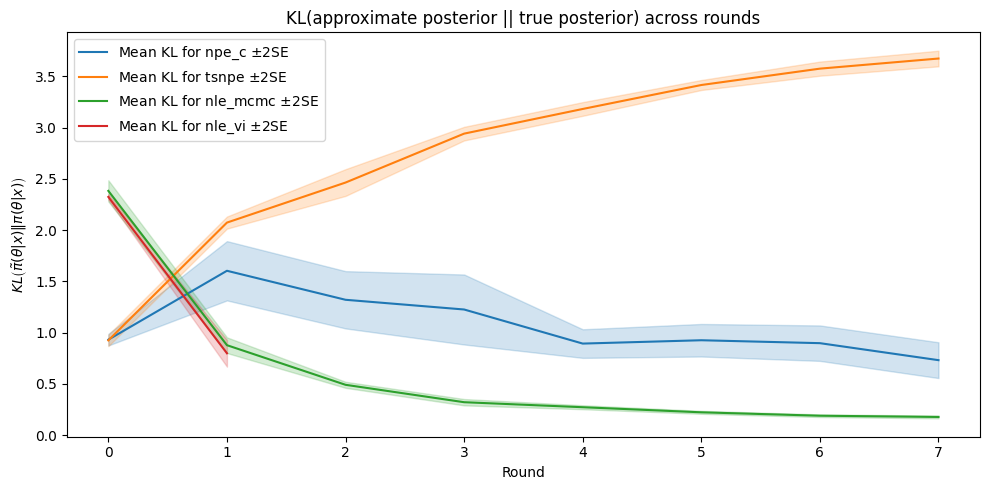

In [9]:
plot_KL_across_rounds(KLs_dicts, exclude_methods=["nre"])